# Testing Tetris with Reinforcement Learning with Tabular Obs (DQN algo)

## C

### Imports

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import random
from itertools import count
import os

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from a_helper import plot_all

from collections import namedtuple, deque
from tetris_env import SHAPES_IDS
from tetris_env import TetrisEnv
from a_helper import save_dqn_model
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

pygame 2.6.1 (SDL 2.28.4, Python 3.12.1)
Hello from the pygame community. https://www.pygame.org/contribute.html


C:\2. PersonalCoding\ia-final-project-tetris-agent\tetris_rl\venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


### Device

In [2]:
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(is_ipython)
print(device)

True
cuda


## Model

In [3]:
class DQN(nn.Module):
    def __init__(self, n_observations, n_actions, h_dim):
        super(DQN, self).__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(n_observations, h_dim),
            nn.LayerNorm(h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim),
            nn.LayerNorm(h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, n_actions)
        )
        
    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

### ReplayMemory

In [4]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

### Action And Optimizer

Epsilon decays after every step

In [5]:
def get_action(state, epsilon, test=False):
    sample = random.random()
    
    # eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    
    if sample > epsilon or test:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

In [6]:
from a_helper import get_six_layer_view
from a_helper import eval_bumpiness, eval_cheese, eval_sum_heights, filter_board_upper_outline, get_upper_outline_idx, eval_holes

### OneHot

In [7]:
def obs_one_hot(obs,env):
    # Obs retrieval
    board = obs["board"]
    queue = obs["queue"]
    piece_type = obs["piece_type"]
    hold_piece = obs["hold_piece"]
    piece_position = obs['piece_position']
    current_piece_n_action = obs["current_piece_n_action"]
    current_piece_rotation = obs["current_piece_rotation"]

    # Search the highest row, then get only the 5 rows below it (including highest)
    six_layer_board, highest_layer_idx = get_six_layer_view(obs["board"])
    
    # Minimize cells to 1
    board = np.where(board > 0, 1, board)
    six_layer_board = np.where(six_layer_board > 0, 1, six_layer_board)
    
    board_outline_idx_vals = get_upper_outline_idx(board) / env.board_height
    
    holes_val = eval_holes(board) / ((env.board_width * env.board_height) - env.board_width)
    cheese_val = eval_cheese(board) / (env.board_width * env.board_height)
    sum_heights_val = eval_sum_heights(board) / (env.board_width * env.board_height)
    bumpiness_val = eval_bumpiness(board) / (env.board_height * (env.board_width - 1))
    highest_layer_idx_val = highest_layer_idx / env.board_height
    
    # Next piece
    first_piece_id = SHAPES_IDS[queue[0]]
    
    queue_one_hot = np.zeros(7+1) # +1 => no_piece => None
    queue_one_hot[first_piece_id] = 1
    
    piece_type_one_hot = np.zeros(7+1) # +1 => no_piece => None
    piece_type_one_hot[SHAPES_IDS[piece_type]] = 1

    hold_piece_one_hot = np.zeros(7+1) # +1 => no_piece => None
    hold_piece_one_hot[SHAPES_IDS[hold_piece]] = 1

    # Posicion
    piece_x_position_val = piece_position[0] / env.board_width
    piece_y_position_val = piece_position[1] / env.board_height

    # Finesse
    current_piece_n_action_val = np.array([min(current_piece_n_action, 20) / 20], dtype=np.float32) # 20 is considered finessen't

    current_piece_rotation_one_hot = np.zeros(4)
    current_piece_rotation_one_hot[current_piece_rotation] = 1

    final = np.concatenate((six_layer_board,
                            board_outline_idx_vals,
                            highest_layer_idx_val,
                            holes_val,
                            cheese_val,
                            sum_heights_val,
                            bumpiness_val,
                            current_piece_n_action_val,
                            queue_one_hot,
                            piece_type_one_hot,
                            hold_piece_one_hot, 
                            piece_x_position_val, 
                            piece_y_position_val, 
                            current_piece_rotation_one_hot,
                           ), axis=None)
    return final

## Hyper

In [8]:
training_period = 250
algo_id = "dqn_tabular_pytorch"
start_episode = 0
steps_done = 0

# Test

## Init

In [9]:
base_env= TetrisEnv(board_width=10,
                board_height=22,
                time_limit_s=120,
                obs_type="dict",
                render_mode=None)

env = base_env
state, info = base_env.reset()
n_actions = base_env.action_space.n
n_observations = len(obs_one_hot(state,base_env))

base_env = TetrisEnv(board_width=10,
                board_height=22,
                time_limit_s=120,
                obs_type="dict",
                render_mode='human')
env = base_env
print(state)
print(n_actions, n_observations)

Using Default internal config
Using Default internal config
{'board': array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'queue': [np.str_('T'), np.str_('S'), np.str_('I'), np.str_('L'), np.s

## Loading model

In [11]:
filename = None
filename = "dqn_tabular_pytorch_999.pth"
# filename = "dqn_tabular_pytorch_16000.pth"
checkpoint_path=f"models/{filename}"
if os.path.exists(checkpoint_path):
    h_dim = 256
    policy_net = DQN(n_observations, n_actions,h_dim).to(device)
    target_net = DQN(n_observations, n_actions,h_dim).to(device)
    
    checkpoint = torch.load(checkpoint_path, weights_only=False,map_location=device)
    start_episode = checkpoint['episode'] + 1
    policy_net.load_state_dict(checkpoint['policy_net'])
    target_net.load_state_dict(checkpoint['target_net'])
    memory = checkpoint['memory']
    env.internal_config = checkpoint['env_internal_config']
    metadata = checkpoint['metadata']
    
    print(f"Loaded checkpoint from episode {start_episode}")
    print(metadata)
    policy_net.eval()
    target_net.eval()
else:
    raise Exception("Checkpoint Not Found")

Loaded checkpoint from episode 1000
{'algorithm': 'DQN from PyTorch Tutorial with tabular data', 'note': 'Como observacion de la queue solo tiene la siguiente pieza, no las 5 siguientes, utiliza reward shaping', 'hyper': {'BATCH_SIZE': 128, 'GAMMA': 0.99, 'EPS_START': 1, 'EPS_END': 0.1, 'EPS_DECAY': 9e-06, 'EPS_DECAY_STRAT': 'Subtract after every step', 'TAU': 0.001, 'LR': 0.0001}}


In [12]:
print(env.internal_config)

{'r_finesse': 0.1, 'p_finesse': 0.01, 'p_holes': 1, 'p_cheese': 1, 'r_max_layer_stack_height': 6, 'r_stack_height': 1, 'p_exp_stack_height': 0.4, 'p_const_stack_height': 0.5, 'p_mult_stack_height': 0.1, 'r_flatness': 1, 'p_mult_bumpiness': 1, 'r_const_clear_lines': 0, 'r_clear_lines': [0, 2, 6, 12, 18], 'r_survive_step': 0, 'r_const_hardrop': 0.01, 'r_softdrop': 0, 'p_game_over': 100, 'p_bug': 10000, 'p_stack_height_values': array([-40.34287935, -27.04264074, -18.12722419, -12.15104175,
        -8.14508687,  -5.459815  ,  -3.65982344,  -2.45325302,
        -1.64446468,  -1.10231764,  -0.73890561,  -0.49530324,
        -0.33201169,  -0.22255409,  -0.14918247,  -0.1       ,
         0.16666667,   0.2       ,   0.25      ,   0.33333333,
         0.5       ,   1.        ])}


## Main Test

i_episode 4
-1371.4881484673606


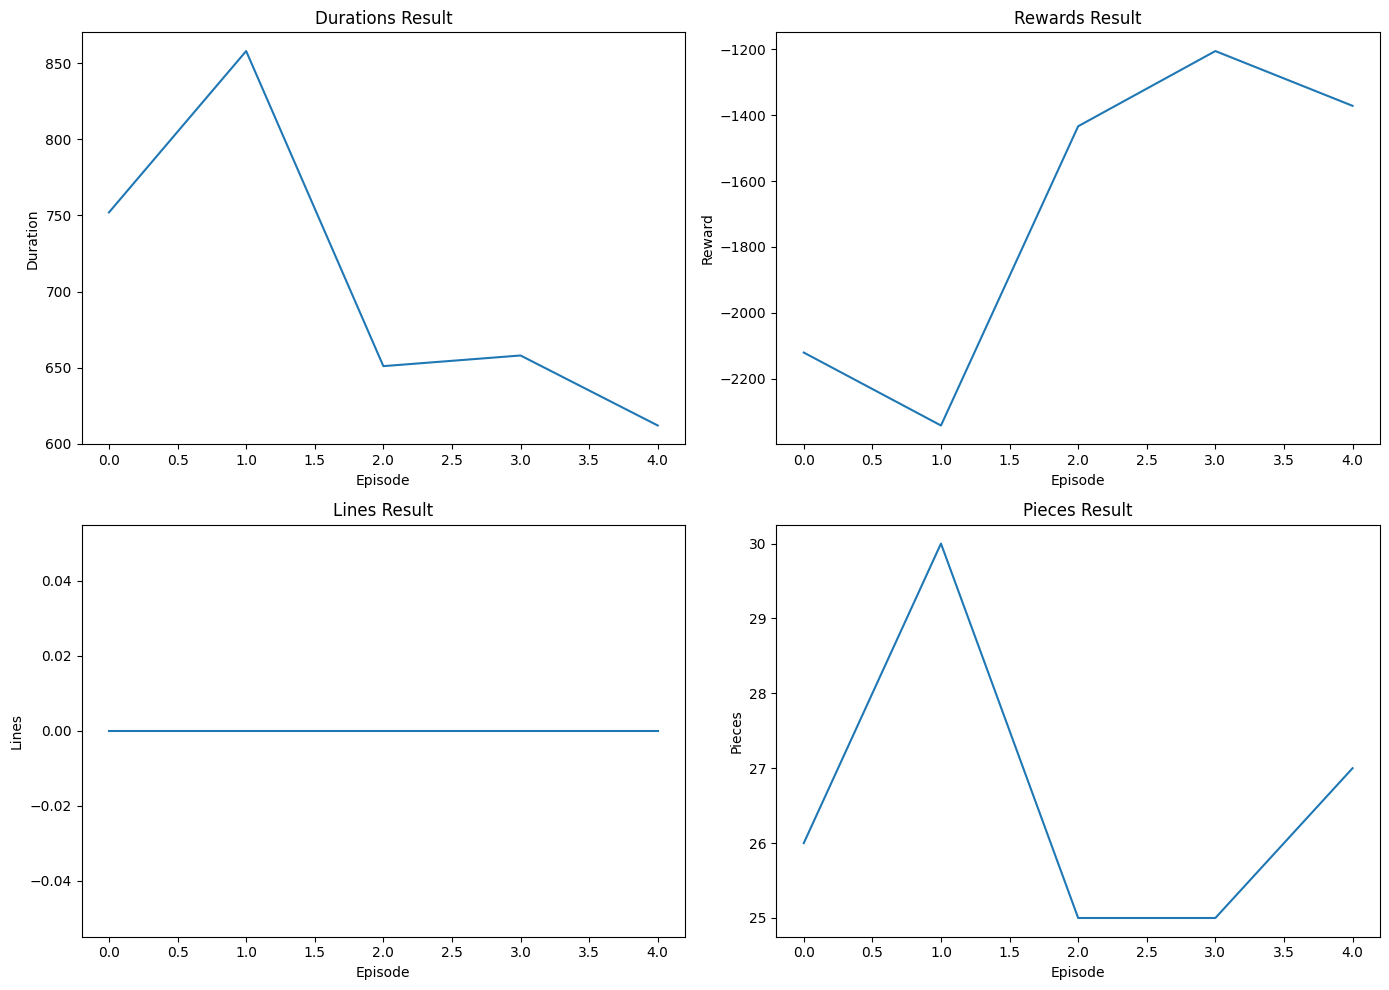

Duration: 706.2
Reward: -1694.6649511868168
Lines: 0.0
Pieces: 26.6
Complete


In [13]:
total_episodes = 5

episode_durations = []
episode_rewards = []
episode_lines = []
episode_pieces = []
for i_episode in range(total_episodes):
    state, info = env.reset()
    state = obs_one_hot(state,env)
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    total_reward = 0
    done = False

    for t in count():
        action = get_action(state, epsilon=0,test=True)
        next_state, reward, terminated, truncated, info = env.step(action.item())
        next_state = obs_one_hot(next_state,env)
        
        reward = torch.tensor([reward], device=device)
        total_reward += reward.item()
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(next_state, dtype=torch.float32, device=device).unsqueeze(0)

        state = next_state

        if done:
            episode_durations.append(t + 1)
            episode_rewards.append(total_reward)
            episode_lines.append(info['lines_cleared'])
            episode_pieces.append(info['pieces_placed'])
            plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces)
            print("i_episode",i_episode)
            print(total_reward)
            break
            
        display.clear_output(wait=True)
    
plot_all(episode_durations,episode_rewards,episode_lines,episode_pieces,save=True,show_result=True,filename=f"plots/temp.png")
print("Duration:", np.mean(episode_durations))
print("Reward:", np.mean(episode_rewards))
print("Lines:", np.mean(episode_lines))
print("Pieces:", np.mean(episode_pieces))
plt.ioff()
plt.show()
env.close()
print('Complete')